# Model Explainability Experiment

### 1 Setup

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
RANDOM_STATE = 42

# Configure NumPy.
rng = np.random.default_rng(seed=RANDOM_STATE)
np.set_printoptions(linewidth=100)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

warnings.filterwarnings("ignore")

#### Dataset

In [3]:
data = [
    [10, 15, 900, 3_650],  # 10 years old car, 15 km millage, 900 km odometer reading costs: $3,650
    [5, 10, 400, 16_600],  # 5 years old car, 10 km millage, 400 km odometer reading costs: $16,600
    [1, 10, 200, 22_000],  # 1 year old car, 10 km millage, 200 km odometer reading costs: $22,000
    [8, 13, 600, 11_330],  # 8 years old car, 13 km millage, 600 km odometer reading costs: $11,330
    [5, 15, 400, 16_650],  # 5 years old car, 15 km millage, 400 km odometer reading costs: $16,650
]
col_names = ["Age", "Millage", "Odometer", "ResalePrice"]

df = pd.DataFrame(data=data, columns=col_names)
df

,Age,Millage,Odometer,ResalePrice
0,10,15,900,3650
1,5,10,400,16600
2,1,10,200,22000
3,8,13,600,11330
4,5,15,400,16650


#### Linear relation b/w Features & Target

In [4]:
X = df.drop(columns="ResalePrice")  # Features
y = df["ResalePrice"]  # Target

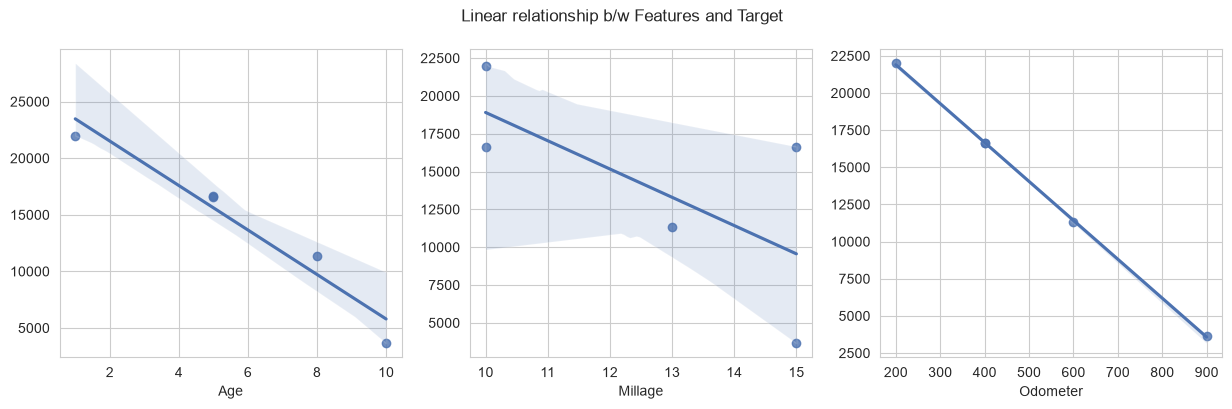

In [5]:
plt.figure(figsize=(15, 4))
plt.suptitle("Linear relationship b/w Features and Target")

for idx, col_name in enumerate(X.columns, start=1):
    plt.subplot(1, 3, idx)
    sns.regplot(x=df[col_name].values, y=df["ResalePrice"].values)
    plt.xlabel(col_name)

plt.show()

### 2 Training Without Scaling

#### Linear Regression Model

In [6]:
model1 = LinearRegression()
model1.fit(X, y)

print("Model coefficients without scaling:", model1.coef_.round(6).tolist())

Model coefficients without scaling: [-100.0, 10.0, -25.0]


##### Model Coefficients

In [7]:
fc1_df = (
    pd.DataFrame(
        data={
            "Feature": model1.feature_names_in_,
            "Coefficient": np.abs(model1.coef_),
        }
    )
    .sort_values(by="Coefficient", ascending=False)
    .reset_index(drop=True)
)
fc1_df

,Feature,Coefficient
0,Age,100.0
1,Odometer,25.0
2,Millage,10.0


#### Properties

Properties of Coefficients without scaling:

- It is **incorrect** to conclude _Age_ is more important than _Odometer_ is more important than _Millage_ in deciding resale price.
- Coefficients are attached to features measured in completely different units.
- Coefficients without feature scaling cannot be used for interpreting feature importance.

#### Example #1

##### Model Explainability

- Training dataset shows a 10 years old car with 15 km millage and 900 km odometer reading costs: \$3,650.
- One year **increase in age** of car keeping all other features as constant should **reduce the resale price** by \$100 (age coefficient).
- Expected resale price to be predicted by a Linear Regression model is \$3,650 - \$100 = \$3,550.

In [8]:
y_pred1 = model1.predict([[11, 15, 900]]).item()
print(
    f"Predicted resale price of 11 years old car with"
    f" 15 km millage and 900 km odometer reading is: ${y_pred1:,.0f}"
)

Predicted resale price of 11 years old car with 15 km millage and 900 km odometer reading is: $3,550


#### Example #2

##### Model Explainability

- Training dataset shows a 10 years old car with 15 km millage and 900 km odometer reading costs: \$3,650.
- One year **decrease in age** of car keeping all other features as constant should **increase the resale price** by \$100 (age coefficient).
- Expected resale price to be predicted by a Linear Regression model is \$3,650 + \$100 = \$3,750.

In [9]:
y_pred2 = model1.predict([[9, 15, 900]]).item()

print(
    f"Predicted resale price of 9 years old car with"
    f" 15 km millage and 900 km odometer reading is: ${y_pred2:,.0f}"
)

Predicted resale price of 9 years old car with 15 km millage and 900 km odometer reading is: $3,750


### 3 Training With Scaling

#### Feature Scaling

In [10]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

##### Scaling parameters

In [11]:
std_df = pd.DataFrame(
    data={
        "Feature": scaler.get_feature_names_out(),
        "mean": scaler.mean_,
        "std": scaler.scale_,
    }
)
std_df

,Feature,mean,std
0,Age,5.8,3.059412
1,Millage,12.6,2.244994
2,Odometer,500.0,236.643191


#### Linear Regression Model

In [12]:
model2 = LinearRegression()
model2.fit(X_scaled, y)

print("Model coefficients after scaling:", model2.coef_.round(6).tolist())

Model coefficients after scaling: [-305.941171, 22.449944, -5916.079783]


##### Model Coefficients

In [13]:
fc2_df = (
    pd.DataFrame(
        data={
            "Feature": model2.feature_names_in_,
            "Coefficient": np.abs(model2.coef_),
        }
    )
    .sort_values(by="Coefficient", ascending=False)
    .reset_index(drop=True)
)
fc2_df

,Feature,Coefficient
0,Odometer,5916.079783
1,Age,305.941171
2,Millage,22.449944


#### Properties

Properties of Coefficients after scaling:

- Model Explainability using coefficients is NOT lost after feature scaling.
- Feature scaling changes the numerical values of the coefficients.
- Scaling does not change the underlying predictive relationship represented by the model.

#### Example #3

In [14]:
age_std = std_df[std_df["Feature"] == "Age"]["std"].item()
age_cof = fc2_df[fc2_df["Feature"] == "Age"]["Coefficient"].item()

print(f"Standard deviation of Age feature: {age_std:.2f}")
print(f"Coefficient of Age feature (after scaling): {age_cof:.2f}")

Standard deviation of Age feature: 3.06
Coefficient of Age feature (after scaling): 305.94


##### Model Explainability

- Training dataset shows a 10 years old car with 15 km millage and 900 km odometer reading costs: \$3,650
- One standard deviation **increase in age** keeping all other features as constant should **decrease resale price** by \$305.94.
- Expected resale price to be predicted by a Linear Regression model is \$3,650 + \$305.94 = \$3,955.94

In [15]:
one_sd_age = 10 + (1 * age_std)
exp_price3 = 3_650 - (1 * age_cof)

print(f"Expected resale price of {round(one_sd_age)} years old car is: ${exp_price3:,.0f}")

Expected resale price of 13 years old car is: $3,344


In [16]:
x3_scaled = scaler.transform([[one_sd_age, 15, 900]])
y_pred3 = model2.predict(x3_scaled).item()

print(
    f"Predicted resale price of {round(one_sd_age)} years old car with"
    f" 15 km millage and 900 km odometer reading is: ${y_pred3:,.0f}"
)

Predicted resale price of 13 years old car with 15 km millage and 900 km odometer reading is: $3,344


##### Observations

- Feature Scaling does not change the predictive outcome of a model.
- Predicted resale price of car - \$3,500 - was same with and without feature scaling.

#### Example #4

In [17]:
two_sd_age = 10 - (2 * age_std)
exp_price4 = 3_650 + (2 * age_cof)

print(f"Expected resale price of {round(two_sd_age)} years old car is: ${exp_price4:,.0f}")

Expected resale price of 4 years old car is: $4,262


##### Model Explainability

- Training dataset shows a 10 years old car with 15 km millage and 900 km odometer reading costs: \$3,650
- Two standard deviation **decrease in age** keeping all other features as constant should **increase resale price** by 2 X \$305.94 = \$611.88.
- \$611.88 is approximately twice the coefficient of age feature.
- Expected resale price to be predicted by a Linear Regression model is \$3,650 + \$611.88 = \$4,261.88

In [18]:
x4_scaled = scaler.transform([[two_sd_age, 15, 900]])
y_pred4 = model2.predict(x4_scaled).item()

print(
    f"Predicted resale price of {round(two_sd_age)} years old car with"
    f" 15 km millage and 900 km odometer reading is: ${y_pred4:,.0f}"
)

Predicted resale price of 4 years old car with 15 km millage and 900 km odometer reading is: $4,262


##### Observations

- Feature Scaling does not change the predictive outcome of a model.
- Predicted resale price of car - \$3,500 - was same with and without feature scaling.

### 4 Feature Importance

#### Coefficients without scaling

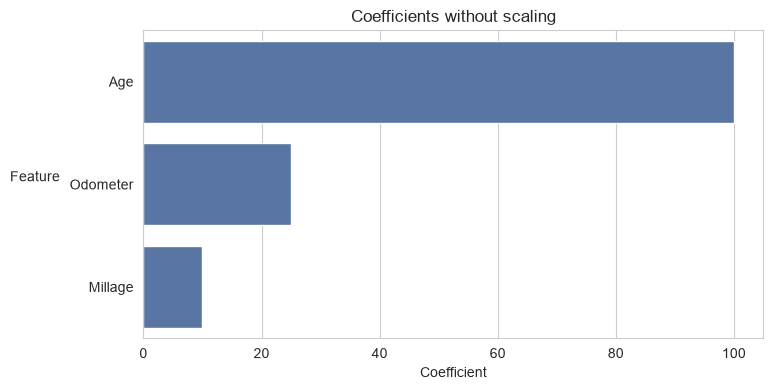

In [19]:
plt.figure(figsize=(8, 4))

sns.barplot(fc1_df, x="Coefficient", y="Feature")
plt.title("Coefficients without scaling")
plt.ylabel("Feature", rotation=0, labelpad=25)

plt.show()

##### Observations

Without feature scaling the coefficients are not comparable and cannot be used to determine feature importance.

#### Coefficients after scaling

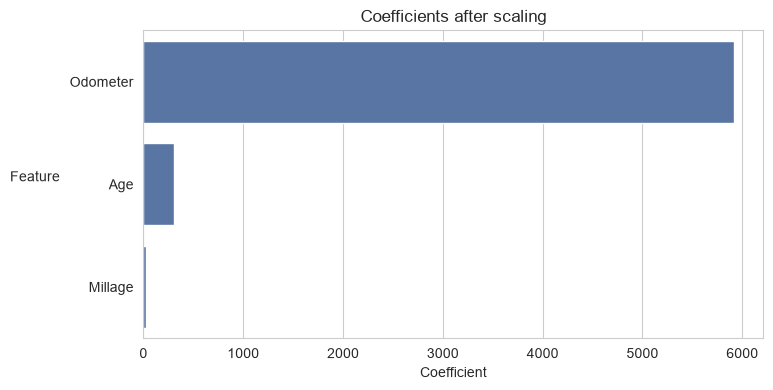

In [20]:
plt.figure(figsize=(8, 4))

sns.barplot(fc2_df, x="Coefficient", y="Feature")
plt.title("Coefficients after scaling")
plt.ylabel("Feature", rotation=0, labelpad=25)

plt.show()

##### Observations

Feature _Odometer_ is more important than _Age_ is more important than _Millage_ in predicting resale price of the car